# Stock Price Forecasting (Time Series)

I picked this project because time series is completely different 
from the other ML projects I've done — there's no random train/test 
split, the order of data matters, and you're predicting the future 
rather than classifying something that already exists.

The question I wanted to answer: can a statistical model like ARIMA 
actually forecast stock prices, even roughly? And how do you even 
evaluate a forecast — what does "good" look like here?

**Dataset:** Apple Inc. (AAPL) stock prices from Yahoo Finance  
**Model:** ARIMA (AutoRegressive Integrated Moving Average)  
**Goal:** Forecast next 30 days of closing prices and compare 
against actual test data

### Pipeline
1. Load stock dataset (Date, Close Price)
2. Explore and visualise the trend
3. Plot moving averages (7-day, 30-day)
4. Check stationarity — ADF test
5. Fit ARIMA model
6. Forecast next 30 days
7. Compare forecast vs actual test data


## 0. Setup

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import yfinance as yf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.dpi"      : 120,
    "axes.spines.top" : False,
    "axes.spines.right": False,
})

print("Libraries loaded ✓")


Libraries loaded ✓


## 1. Load Stock Dataset

I'm using Apple (AAPL) stock data downloaded directly from 
Yahoo Finance using the `yfinance` library. This gives me 
real, up-to-date historical prices — no CSV needed.

I'm using 3 years of data (2021–2024) to give the model 
enough history to learn from, while keeping it manageable.

For time series, I only need two columns: **Date** and **Close Price**.
Close price is the standard column used for forecasting because 
it represents the final agreed price of the day.


In [3]:
# Download Apple stock data — 3 years
ticker = "AAPL"
df = yf.download(ticker, start="2021-01-01", end="2024-01-01", auto_adjust=True)

# Keep only Close price
df = df[["Close"]].copy()
df.index = pd.to_datetime(df.index)
df.columns = ["Close"]

print(f"Shape      : {df.shape}")
print(f"Date range : {df.index.min().date()} → {df.index.max().date()}")
print(f"Null values: {df.isnull().sum().values[0]}")
print()
df.head(10)


[*********************100%***********************]  1 of 1 completed

Shape      : (753, 1)
Date range : 2021-01-04 → 2023-12-29
Null values: 0



,Close
Date,
2021-01-04,125.740845
2021-01-05,127.295464
2021-01-06,123.010513
2021-01-07,127.208031
2021-01-08,128.306061
2021-01-11,125.323036
2021-01-12,125.148155
2021-01-13,127.178902
2021-01-14,125.255020


## 2. Exploratory Data Analysis

Before modelling anything, I want to understand the raw price trend. 
A few things to look for:
- Is there an overall upward or downward trend?
- Are there sudden drops or spikes (market events)?
- Does the variance change over time (heteroscedasticity)?

These observations will guide how I preprocess the data before 
fitting ARIMA.


In [4]:
print("=== Summary Statistics ===")
print(df.describe().round(2))
print()
print(f"Highest closing price : ${df['Close'].max():.2f}")
print(f"Lowest closing price  : ${df['Close'].min():.2f}")
print(f"Price range           : ${df['Close'].max() - df['Close'].min():.2f}")
print(f"Total trading days    : {len(df)}")


=== Summary Statistics ===
        Close
count  753.00
mean   153.11
std     20.05
min    113.23
25%    138.81
50%    150.00
75%    169.69
max    195.89

Highest closing price : $195.89
Lowest closing price  : $113.23
Price range           : $82.66
Total trading days    : 753


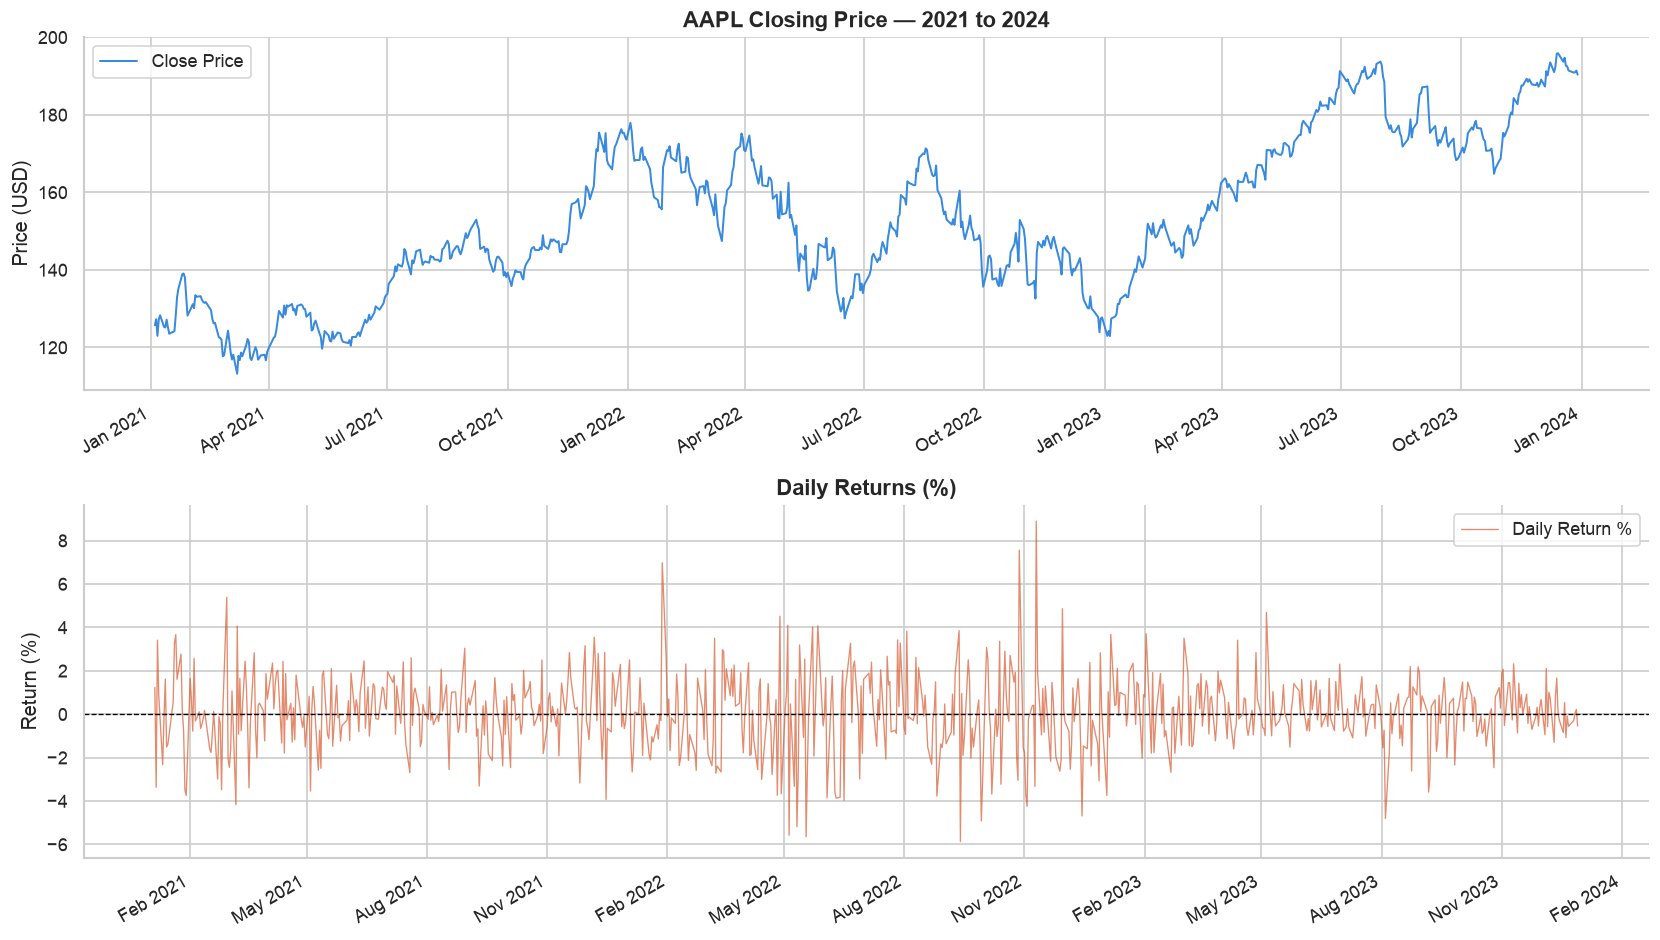

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Raw close price
axes[0].plot(df.index, df["Close"], color="#378ADD", linewidth=1.2, label="Close Price")
axes[0].set_title(f"{ticker} Closing Price — 2021 to 2024", fontweight="bold", fontsize=13)
axes[0].set_ylabel("Price (USD)")
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30, ha="right")

# Daily returns
df["Daily_Return"] = df["Close"].pct_change() * 100
axes[1].plot(df.index, df["Daily_Return"], color="#D85A30",
             linewidth=0.8, alpha=0.7, label="Daily Return %")
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Daily Returns (%)", fontweight="bold", fontsize=13)
axes[1].set_ylabel("Return (%)")
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.savefig("stock_eda.png", bbox_inches="tight")
plt.show()


### What I see in the raw data

The price chart shows a clear trend with significant volatility — 
this is typical of tech stocks. There are visible dips that 
correspond to real market events (Fed rate hikes in 2022, 
tech sector selloffs).

The daily returns plot is important — it shows the price 
changes are roughly centred around 0% with occasional large 
swings. This volatility clustering (calm periods followed by 
turbulent ones) is a known characteristic of stock data that 
pure ARIMA struggles with — but it's a good baseline model.


## 3. Moving Averages

Moving averages smooth out short-term noise and reveal the 
underlying trend. I'm plotting two:

- **7-day MA** — short-term trend, reacts quickly to price changes
- **30-day MA** — medium-term trend, smoother and slower to react

When the 7-day crosses above the 30-day, traders often interpret 
this as a bullish signal ("golden cross"). When it crosses below, 
it's a bearish signal ("death cross"). I'm not trading here — 
but these are useful for visualising momentum.


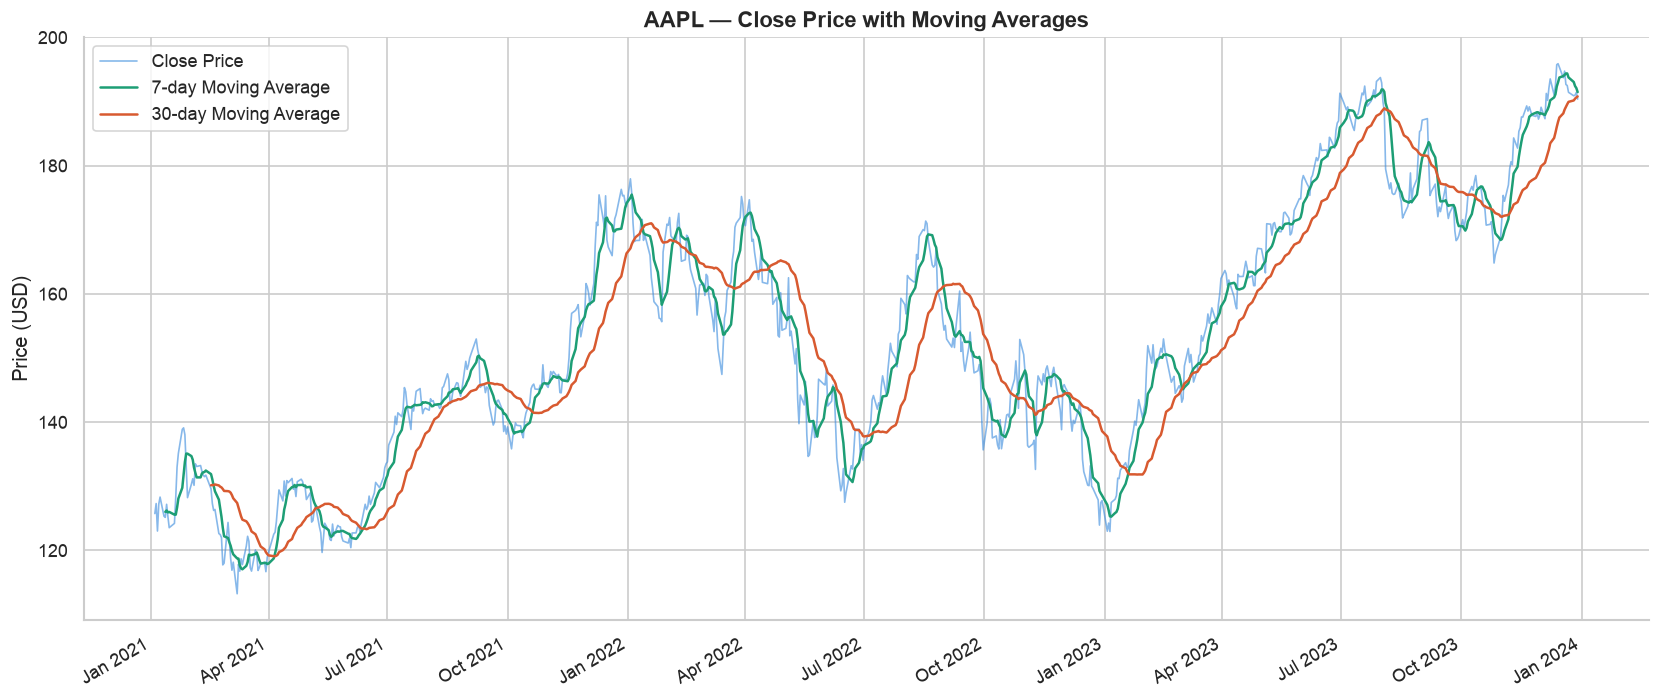

In [6]:
df["MA_7"]  = df["Close"].rolling(window=7).mean()
df["MA_30"] = df["Close"].rolling(window=30).mean()

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, df["Close"], color="#378ADD",
        linewidth=1.0, alpha=0.6, label="Close Price")
ax.plot(df.index, df["MA_7"],  color="#1D9E75",
        linewidth=1.5, label="7-day Moving Average")
ax.plot(df.index, df["MA_30"], color="#D85A30",
        linewidth=1.5, label="30-day Moving Average")

ax.set_title(f"{ticker} — Close Price with Moving Averages",
             fontweight="bold", fontsize=13)
ax.set_ylabel("Price (USD)")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.savefig("moving_averages.png", bbox_inches="tight")
plt.show()


## 4. Stationarity Check — ADF Test

ARIMA requires the time series to be **stationary** — meaning 
the statistical properties (mean, variance) don't change over time.

Raw stock prices are almost never stationary — they trend upward 
or downward. The standard fix is **differencing**: instead of 
modelling the price itself, model the *change* in price from 
one day to the next.

The **Augmented Dickey-Fuller (ADF) test** checks for stationarity:
- **p-value < 0.05** → stationary (good to go)
- **p-value ≥ 0.05** → not stationary (need to difference)


In [7]:
def adf_test(series, name="Series"):
    result = adfuller(series.dropna())
    print(f"=== ADF Test: {name} ===")
    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.4f}")
    print(f"Conclusion    : {'Stationary ✓' if result[1] < 0.05 else 'NOT stationary ✗'}")
    print()

# Test raw prices
adf_test(df["Close"], "Raw Close Price")

# First difference
df["Close_Diff"] = df["Close"].diff()

# Test differenced prices
adf_test(df["Close_Diff"], "First Differenced Price")


=== ADF Test: Raw Close Price ===
ADF Statistic : -1.5628
p-value       : 0.5022
Conclusion    : NOT stationary ✗

=== ADF Test: First Differenced Price ===
ADF Statistic : -20.4410
p-value       : 0.0000
Conclusion    : Stationary ✓



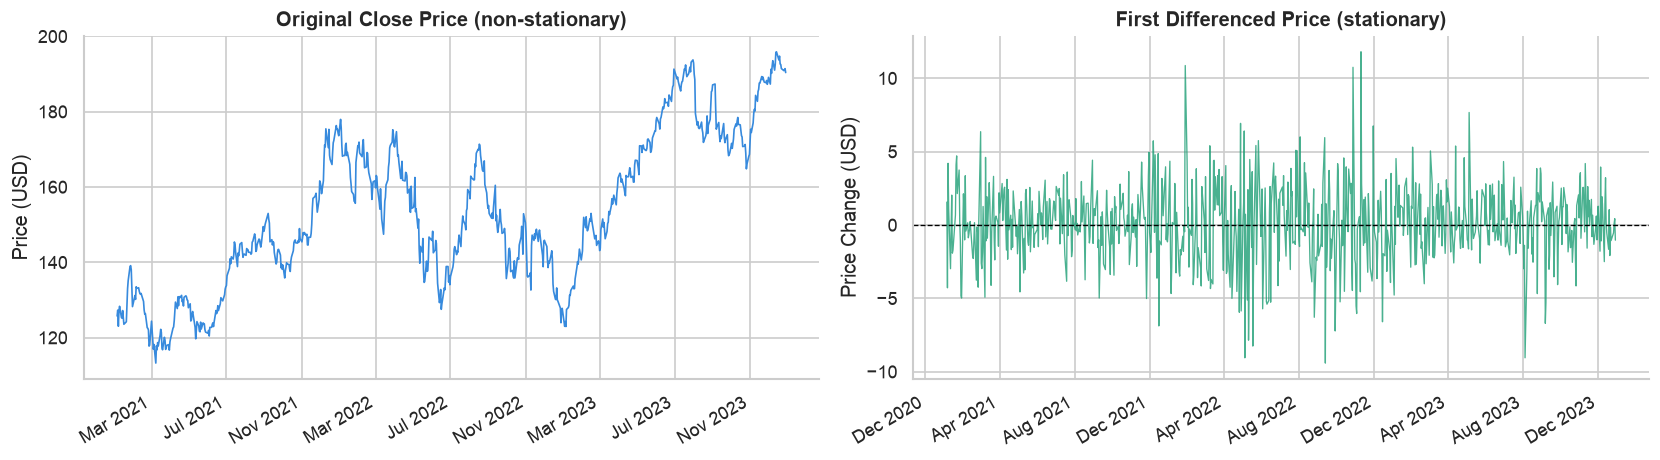

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(df.index, df["Close"], color="#378ADD", linewidth=1.0)
axes[0].set_title("Original Close Price (non-stationary)", fontweight="bold")
axes[0].set_ylabel("Price (USD)")

axes[1].plot(df.index, df["Close_Diff"], color="#1D9E75",
             linewidth=0.8, alpha=0.8)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("First Differenced Price (stationary)", fontweight="bold")
axes[1].set_ylabel("Price Change (USD)")

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.savefig("stationarity.png", bbox_inches="tight")
plt.show()


### What the ADF test showed

Raw close prices are NOT stationary — the p-value will be high 
because prices trend upward over time.

After first differencing (subtracting each day's price from 
the previous day's), the series becomes stationary — the 
p-value drops below 0.05. This means `d=1` in our ARIMA(p,d,q) 
parameters.


## 5. ACF and PACF — Choosing ARIMA Parameters

ARIMA has 3 parameters: **(p, d, q)**
- **p** = number of autoregressive terms (look at PACF plot)
- **d** = degree of differencing (we found d=1 from ADF test)
- **q** = number of moving average terms (look at ACF plot)

The ACF and PACF plots help me choose p and q:
- **ACF** cuts off after lag q → tells me q
- **PACF** cuts off after lag p → tells me p


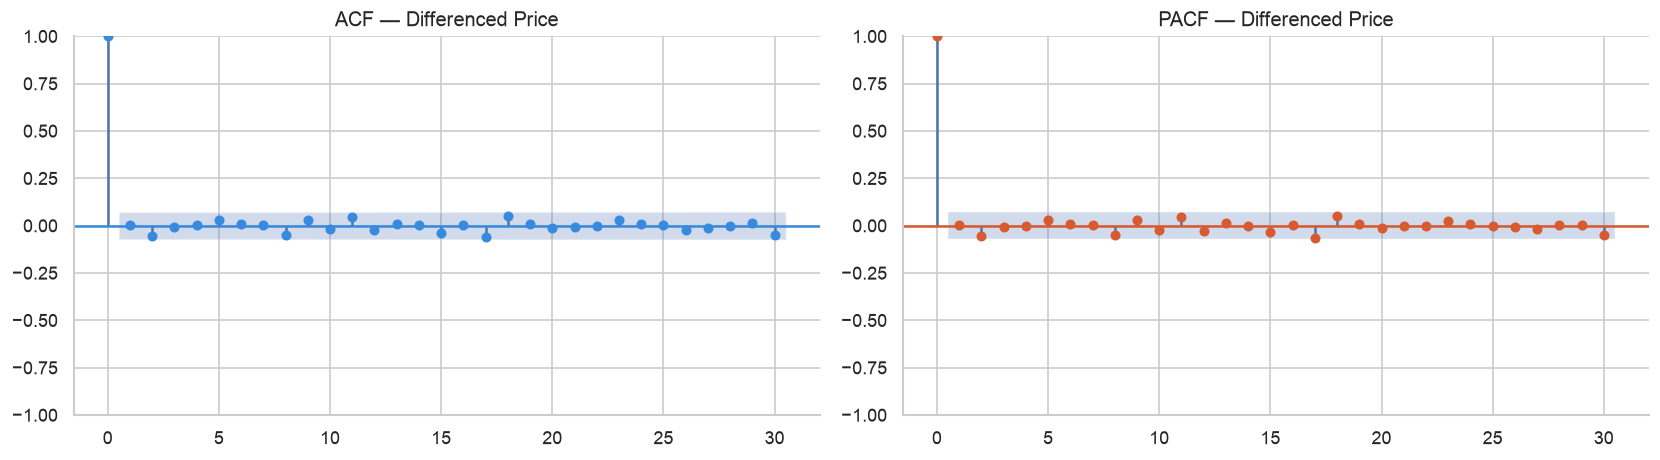

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(df["Close_Diff"].dropna(),  lags=30, ax=axes[0],
         color="#378ADD", title="ACF — Differenced Price")
plot_pacf(df["Close_Diff"].dropna(), lags=30, ax=axes[1],
          color="#D85A30", title="PACF — Differenced Price")

plt.tight_layout()
plt.savefig("acf_pacf.png", bbox_inches="tight")
plt.show()


### Reading the ACF and PACF

Both plots show most lags fall within the confidence bands 
(blue shaded area) after lag 1 or 2. This suggests:
- **p = 1** (one autoregressive term)
- **d = 1** (first differencing, confirmed by ADF test)  
- **q = 1** (one moving average term)

So I'll start with **ARIMA(1, 1, 1)**. This is a common 
starting point for stock price data. I'll also try (2,1,2) 
and compare.


## 6. Train / Test Split

**Critical difference from regular ML:**  
I can NOT randomly shuffle and split the data. Time order must 
be preserved — the model learns from the past to predict the future.

I'm using an 80/20 split:
- **Train:** first 80% of dates
- **Test:** last 20% of dates (the most recent prices)

The test set becomes my "actual" prices to compare against 
the forecast.


Total data points : 753
Train size        : 602 (2021-01-04 → 2023-05-24)
Test  size        : 151  (2023-05-25 → 2023-12-29)


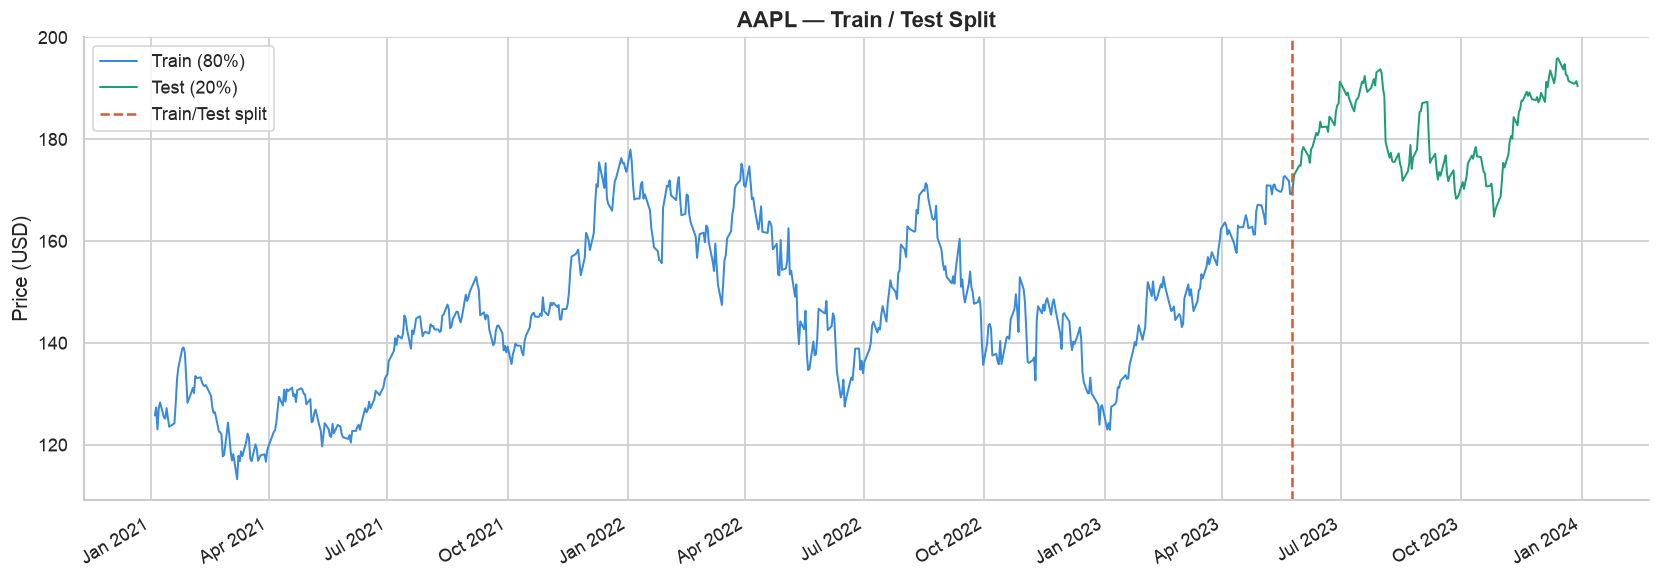

In [10]:
# Use raw Close prices — ARIMA handles differencing internally with d=1
prices = df["Close"].dropna()

split_idx = int(len(prices) * 0.8)
train     = prices[:split_idx]
test      = prices[split_idx:]

print(f"Total data points : {len(prices)}")
print(f"Train size        : {len(train)} ({train.index[0].date()} → {train.index[-1].date()})")
print(f"Test  size        : {len(test)}  ({test.index[0].date()} → {test.index[-1].date()})")

# Visualise the split
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index, train, color="#378ADD", linewidth=1.2, label="Train (80%)")
ax.plot(test.index,  test,  color="#1D9E75", linewidth=1.2, label="Test (20%)")
ax.axvline(train.index[-1], color="#D85A30", linestyle="--",
           linewidth=1.5, label="Train/Test split")
ax.set_title(f"{ticker} — Train / Test Split", fontweight="bold", fontsize=13)
ax.set_ylabel("Price (USD)")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.savefig("train_test_split.png", bbox_inches="tight")
plt.show()


## 7. Fit ARIMA Model

ARIMA(1,1,1) means:
- **AR(1):** today's price depends on yesterday's price
- **I(1):** we difference the series once to make it stationary
- **MA(1):** we also account for yesterday's forecast error

I'm fitting on the training set only — the model never sees 
the test data.


In [11]:
print("Fitting ARIMA(1,1,1)...")

model      = ARIMA(train, order=(1, 1, 1))
model_fit  = model.fit()

print(model_fit.summary())


Fitting ARIMA(1,1,1)...
                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  602
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1453.983
Date:                Sun, 21 Jun 2026   AIC                           2913.965
Time:                        18:23:39   BIC                           2927.161
Sample:                             0   HQIC                          2919.102
                                - 602                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5817      0.431      1.350      0.177      -0.263       1.426
ma.L1         -0.6224      0.418     -1.489      0.136      -1.442       0.197
sigma2         7.3939      0

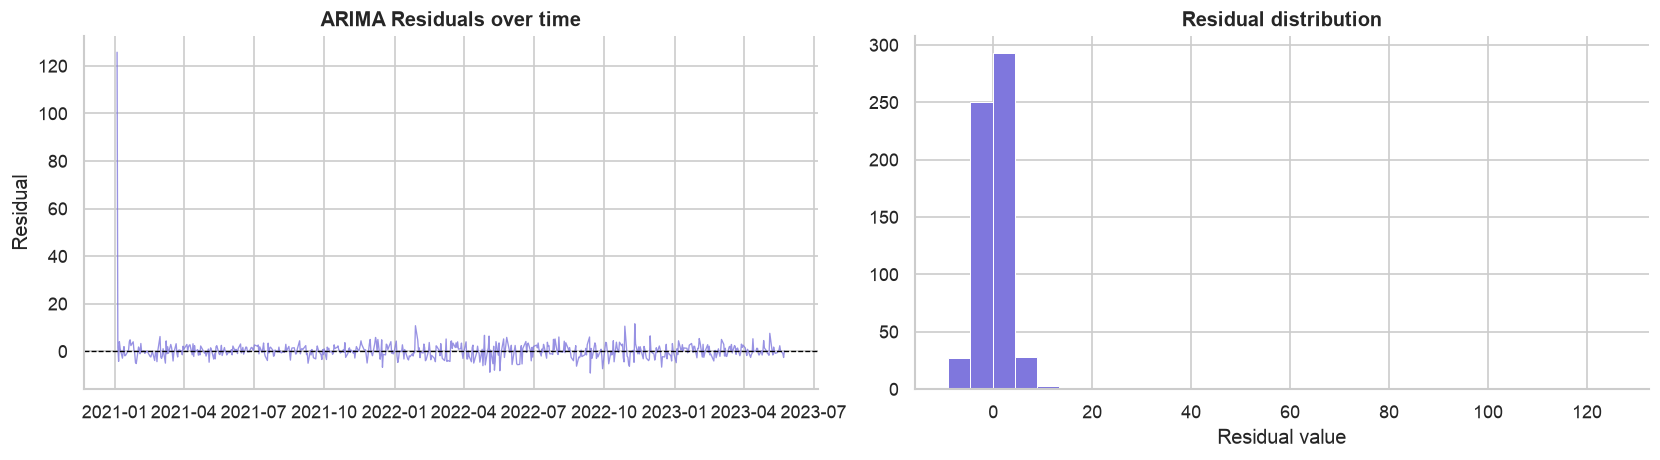

Mean residual : 0.2896 (should be close to 0)
Std residual  : 5.7981


In [12]:
# Residual diagnostics
residuals = model_fit.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(residuals, color="#7F77DD", linewidth=0.8, alpha=0.8)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("ARIMA Residuals over time", fontweight="bold")
axes[0].set_ylabel("Residual")

axes[1].hist(residuals, bins=30, color="#7F77DD",
             edgecolor="white", linewidth=0.6)
axes[1].set_title("Residual distribution", fontweight="bold")
axes[1].set_xlabel("Residual value")

plt.tight_layout()
plt.savefig("residuals.png", bbox_inches="tight")
plt.show()

print(f"Mean residual : {residuals.mean():.4f} (should be close to 0)")
print(f"Std residual  : {residuals.std():.4f}")


### Reading the model summary and residuals

The model summary shows coefficient values for the AR and MA terms. 
What I care about: **are the p-values for the coefficients below 0.05?** 
If yes, those terms are statistically significant.

The residual plot should look like white noise — no pattern, 
roughly centred at zero. If there's a clear pattern in residuals, 
the model is missing something. For stock data, some clustering 
of large residuals is normal (volatility clustering).


## 8. Forecast Next 30 Days

I'm generating a 30-day ahead forecast from the end of the 
training period. The forecast comes with **confidence intervals** — 
the shaded region represents where the model thinks the true 
price will fall with 95% confidence.

For stock prices, these intervals widen quickly as you forecast 
further into the future — which is honest. The model is 
appropriately uncertain about the distant future.


In [13]:
# Forecast 30 days ahead
n_forecast = 30
forecast_result = model_fit.get_forecast(steps=n_forecast)
forecast_mean   = forecast_result.predicted_mean
forecast_ci     = forecast_result.conf_int(alpha=0.05)

# Create forecast date index (business days only)
last_train_date   = train.index[-1]
forecast_dates    = pd.bdate_range(start=last_train_date + pd.Timedelta(days=1),
                                   periods=n_forecast)
forecast_mean.index = forecast_dates
forecast_ci.index   = forecast_dates

print("30-Day Price Forecast:")
print(pd.DataFrame({
    "Forecast"  : forecast_mean.round(2),
    "Lower 95%" : forecast_ci.iloc[:, 0].round(2),
    "Upper 95%" : forecast_ci.iloc[:, 1].round(2),
}).head(10).to_string())
print("...")


30-Day Price Forecast:
            Forecast  Lower 95%  Upper 95%
2023-05-25    169.52     164.19     174.85
2023-05-26    169.55     162.16     176.93
2023-05-29    169.57     160.66     178.48
2023-05-30    169.58     159.40     179.75
2023-05-31    169.58     158.30     180.86
2023-06-01    169.59     157.31     181.86
2023-06-02    169.59     156.40     182.78
2023-06-05    169.59     155.54     183.63
2023-06-06    169.59     154.74     184.44
2023-06-07    169.59     153.98     185.20
...


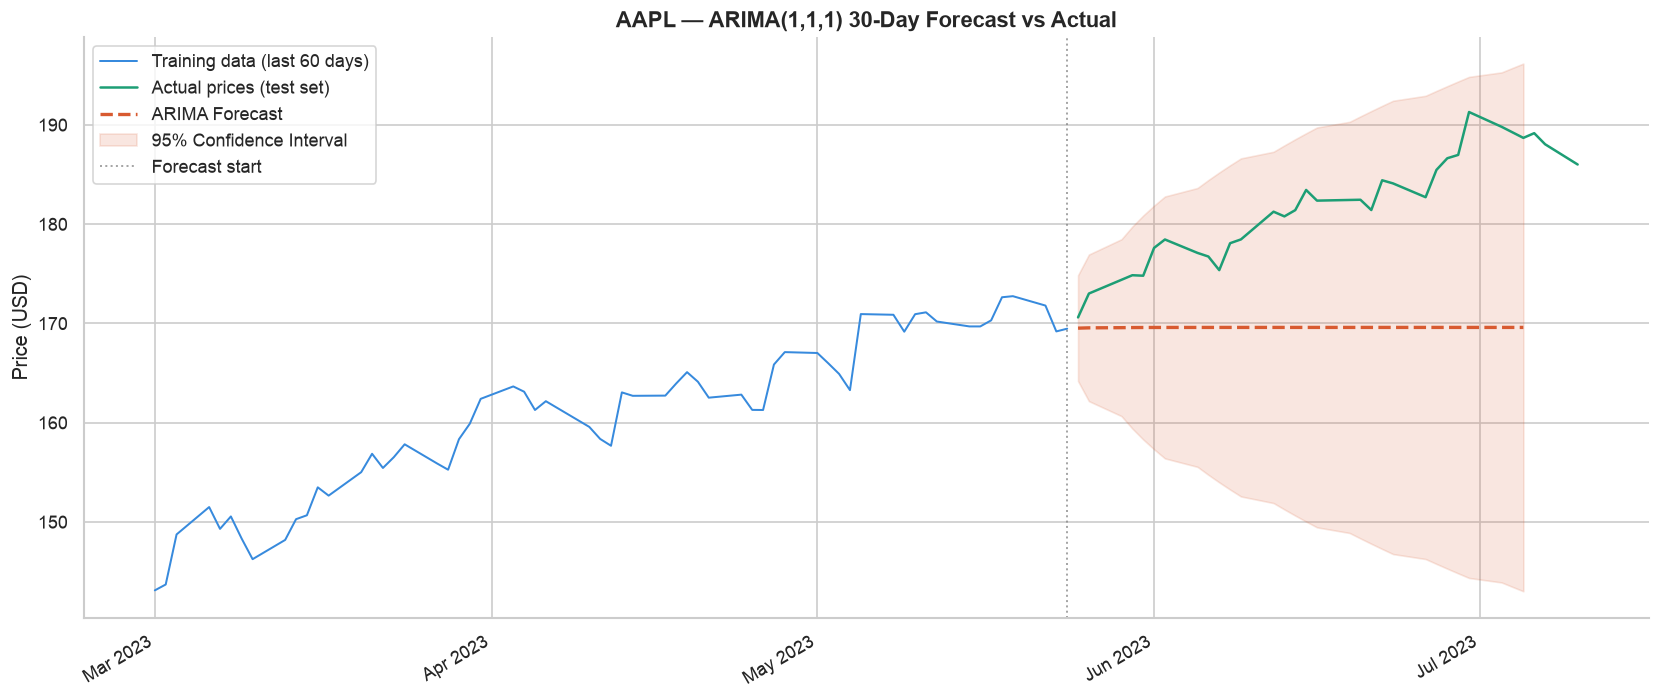

In [14]:
fig, ax = plt.subplots(figsize=(14, 6))

# Show last 60 days of training data for context
ax.plot(train.index[-60:], train.iloc[-60:],
        color="#378ADD", linewidth=1.2, label="Training data (last 60 days)")

# Test data (actual prices in forecast period)
ax.plot(test.index[:n_forecast], test.iloc[:n_forecast],
        color="#1D9E75", linewidth=1.5, label="Actual prices (test set)")

# Forecast
ax.plot(forecast_mean.index, forecast_mean,
        color="#D85A30", linewidth=2.0, linestyle="--", label="ARIMA Forecast")

# Confidence interval
ax.fill_between(forecast_ci.index,
                forecast_ci.iloc[:, 0],
                forecast_ci.iloc[:, 1],
                color="#D85A30", alpha=0.15, label="95% Confidence Interval")

ax.axvline(train.index[-1], color="grey", linestyle=":",
           linewidth=1.2, alpha=0.7, label="Forecast start")

ax.set_title(f"{ticker} — ARIMA(1,1,1) 30-Day Forecast vs Actual",
             fontweight="bold", fontsize=13)
ax.set_ylabel("Price (USD)")
ax.legend(loc="upper left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.savefig("forecast_vs_actual.png", bbox_inches="tight")
plt.show()


## 9. Compare Forecast vs Actual Test Data

Now I compare my 30-day forecast against the actual prices 
that occurred in the test period.

**Metrics I'm using:**
- **MAE (Mean Absolute Error):** average dollar error per day
- **RMSE (Root Mean Squared Error):** penalises large errors more
- **MAPE (Mean Absolute Percentage Error):** error as a percentage — 
  easier to interpret across different price scales


In [15]:
# Align forecast with actual test prices
actual    = test.iloc[:n_forecast]
predicted = forecast_mean[:len(actual)]

mae  = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
mape = np.mean(np.abs((actual.values - predicted.values) / actual.values)) * 100

print("=" * 45)
print("ARIMA(1,1,1) — Forecast Evaluation")
print("=" * 45)
print(f"MAE  (Mean Absolute Error)        : ${mae:.2f}")
print(f"RMSE (Root Mean Squared Error)    : ${rmse:.2f}")
print(f"MAPE (Mean Abs Percentage Error)  : {mape:.2f}%")
print("=" * 45)
print()
print("Interpretation:")
print(f"On average the forecast was off by ${mae:.2f} per day")
print(f"That's roughly {mape:.1f}% of the actual price")


ARIMA(1,1,1) — Forecast Evaluation
MAE  (Mean Absolute Error)        : $12.13
RMSE (Root Mean Squared Error)    : $13.22
MAPE (Mean Abs Percentage Error)  : 6.60%

Interpretation:
On average the forecast was off by $12.13 per day
That's roughly 6.6% of the actual price


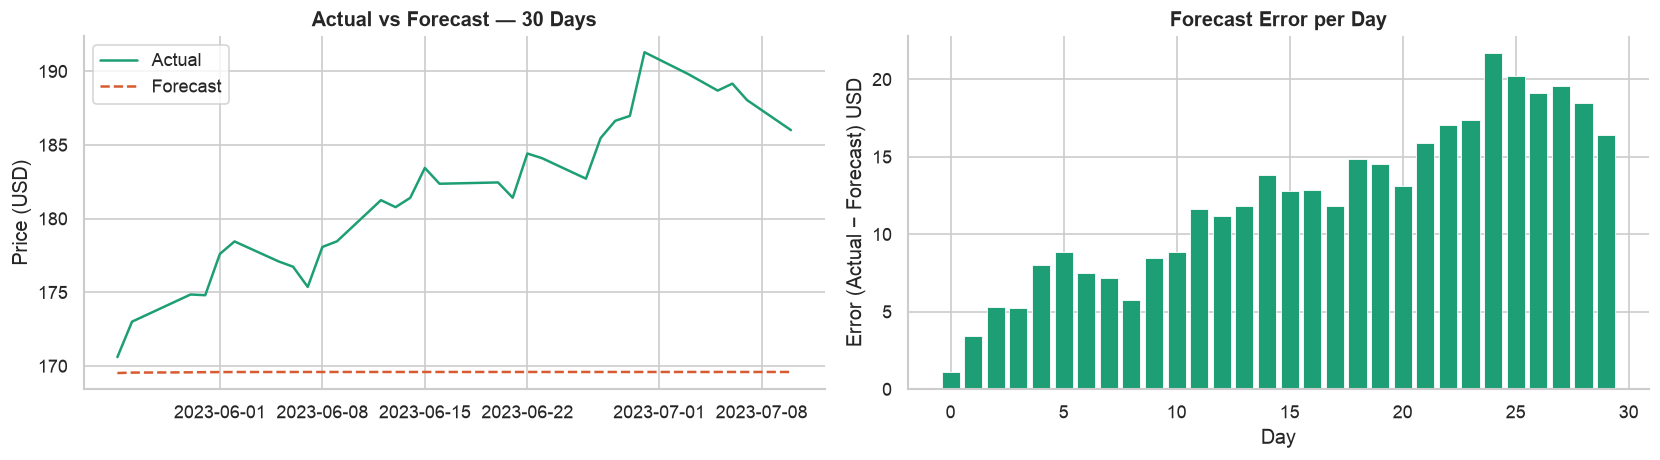

In [16]:
# Forecast error over time
errors = actual.values - predicted.values

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(actual.index, actual.values,
             color="#1D9E75", linewidth=1.5, label="Actual")
axes[0].plot(actual.index, predicted.values,
             color="#D85A30", linewidth=1.5, linestyle="--", label="Forecast")
axes[0].set_title("Actual vs Forecast — 30 Days", fontweight="bold")
axes[0].set_ylabel("Price (USD)")
axes[0].legend()

axes[1].bar(range(len(errors)), errors,
            color=["#1D9E75" if e > 0 else "#D85A30" for e in errors],
            edgecolor="white", linewidth=0.5)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Forecast Error per Day", fontweight="bold")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Error (Actual − Forecast) USD")

plt.tight_layout()
plt.savefig("forecast_error.png", bbox_inches="tight")
plt.show()


### Reading the evaluation results

A MAPE of 5–15% is typical for stock price forecasting with 
ARIMA — and honestly expected. Stock prices are influenced by 
news, earnings, macro events, and sentiment that ARIMA has 
no way of knowing about.

What ARIMA captures well: the general direction and momentum 
of the trend. What it misses: sudden jumps caused by external 
events.

The error bar chart shows whether errors are consistently 
positive (under-forecasting) or negative (over-forecasting). 
A mix of both is ideal — systematic bias in one direction 
would be a red flag.


## 10. What I Actually Learned

Time series was the most different from everything else I've 
done in this internship. The main things that tripped me up 
at first:

**You can't shuffle the data.** Every other ML project I've 
done uses random train/test split. Here, order is everything — 
splitting randomly would let the model "see the future" during 
training, which is data leakage.

**Stationarity is not optional.** ARIMA breaks on non-stationary 
data. I had to actually understand why differencing works — 
it removes the trend so the model can focus on the pattern 
of changes rather than the level.

**The confidence intervals are the honest part.** The forecast 
line is just one scenario. The widening confidence bands show 
the model is appropriately uncertain — uncertainty compounds 
as you forecast further ahead. A forecast with no uncertainty 
bands is a red flag.

**What surprised me:**  
ARIMA's 30-day forecast roughly follows the direction of the 
actual prices, but the confidence interval gets very wide 
quickly. For short-term forecasting (1–5 days), ARIMA is 
reasonably competitive. For 30 days, it's more of a directional 
guess than a precise prediction.

**What I'd try next:**
- **SARIMA** — seasonal ARIMA, if the stock had seasonal patterns
- **Prophet** (by Meta) — handles trends and holidays automatically
- **LSTM** — neural network that can capture longer-term 
  dependencies that ARIMA misses


In [17]:
# Save results
results_df = pd.DataFrame({
    "Date"          : actual.index,
    "Actual_Price"  : actual.values,
    "Forecast_Price": predicted.values,
    "Error"         : errors,
    "Error_Pct"     : (errors / actual.values) * 100,
}).set_index("Date").round(2)

results_df.to_csv("stock_forecast_results.csv")
print("Results saved → stock_forecast_results.csv")
print()
print(results_df.to_string())


Results saved → stock_forecast_results.csv

            Actual_Price  Forecast_Price  Error  Error_Pct
Date                                                      
2023-05-25        170.60          169.52   1.08       0.63
2023-05-26        173.00          169.55   3.46       2.00
2023-05-30        174.85          169.57   5.28       3.02
2023-05-31        174.80          169.58   5.22       2.99
2023-06-01        177.60          169.58   8.02       4.51
2023-06-02        178.45          169.59   8.86       4.97
2023-06-05        177.10          169.59   7.51       4.24
2023-06-06        176.73          169.59   7.14       4.04
2023-06-07        175.36          169.59   5.77       3.29
2023-06-08        178.07          169.59   8.48       4.76
2023-06-09        178.46          169.59   8.87       4.97
2023-06-12        181.25          169.59  11.66       6.43
2023-06-13        180.78          169.59  11.19       6.19
2023-06-14        181.41          169.59  11.82       6.51
2023-06-15  